### Creating data to view and fit

In [1]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [2]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [3]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [4]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


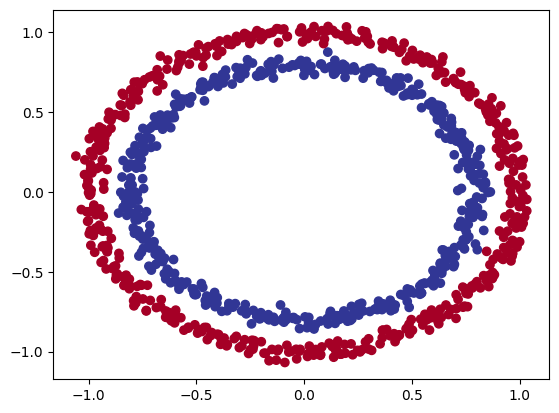

In [5]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [6]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [8]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [9]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [10]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)



Epoch 1/5


32/32 [==============================] - 1s 2ms/step - loss: 1.5026 - accuracy: 0.4740
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 0.7109 - accuracy: 0.4930
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 0.7006 - accuracy: 0.4930
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 0.6960 - accuracy: 0.4970
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 0.6945 - accuracy: 0.4710


In [11]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [12]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [13]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [14]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6944 - accuracy: 0.5000


[0.6943852305412292, 0.5]

### Improving our model

In [15]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 2.2342 - accuracy: 0.5000
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7425 - accuracy: 0.5000
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7074 - accuracy: 0.5000
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6978 - accuracy: 0.5000
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6949 - accuracy: 0.4650
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6941 - accuracy: 0.4740
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6942 - accuracy: 0.5060
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6952 - accuracy: 0.4960
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6953 - accuracy: 0.4990
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6944 - accuracy: 0.4470
Epoch 11/

In [16]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6959 - accuracy: 0.5060


[0.6959262490272522, 0.5059999823570251]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [17]:
import numpy as np

In [18]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 [==============================] - 0s 1ms/step
doing binary classification


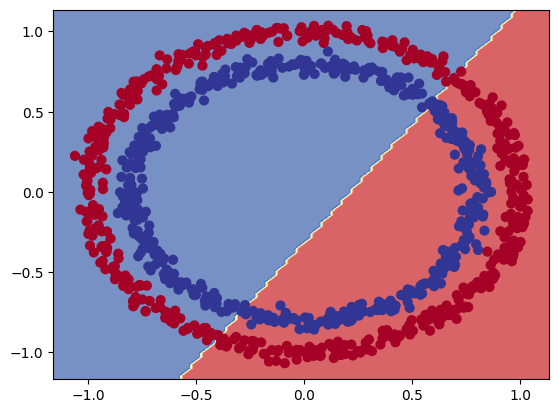

In [19]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [20]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 0s 1ms/step - loss: 5.4282 - accuracy: 0.4790
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 5.3803 - accuracy: 0.4790
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 5.2761 - accuracy: 0.4780
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 5.1645 - accuracy: 0.4750
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 5.0578 - accuracy: 0.4760
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 4.9434 - accuracy: 0.4750
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 4.9137 - accuracy: 0.4740
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 4.8322 - accuracy: 0.4800
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 4.6594 - accuracy: 0.4800
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 4.6032 - accuracy: 0.4780
Epoch 11/

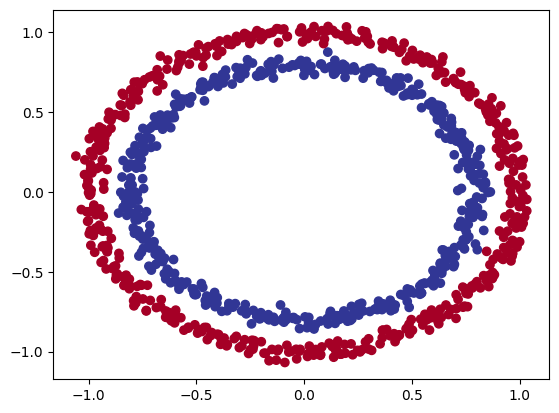

In [21]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 1ms/step
doing binary classification


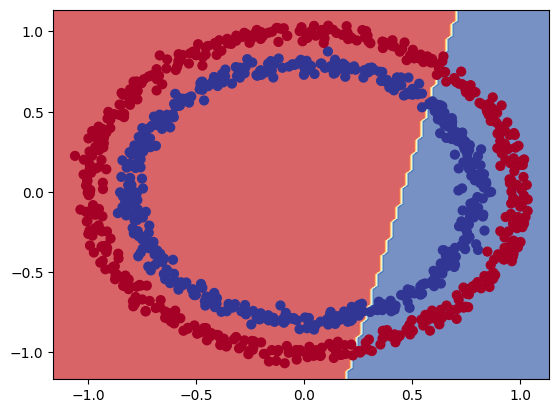

In [22]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [23]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7472 - accuracy: 0.4840
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7298 - accuracy: 0.4840
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7270 - accuracy: 0.4830
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7240 - accuracy: 0.4830
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 5.7131 - accuracy: 0.4830
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 5.6964 - accuracy: 0.4820
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 5.6928 - accuracy: 0.4810
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 5.6740 - accuracy: 0.4800
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 5.6732 - accuracy: 0.4800
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 5.6728 - accuracy: 0.4800
Epoch 11/

In [24]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 2.9799 - accuracy: 0.4680
Epoch 2/250
32/32 [==============================] - 0s 1ms/step - loss: 2.2577 - accuracy: 0.4660
Epoch 3/250
32/32 [==============================] - 0s 1ms/step - loss: 1.4866 - accuracy: 0.4240
Epoch 4/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8971 - accuracy: 0.4330
Epoch 5/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8451 - accuracy: 0.4390
Epoch 6/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8252 - accuracy: 0.4370
Epoch 7/250
32/32 [==============================] - 0s 1ms/step - loss: 0.8063 - accuracy: 0.4410
Epoch 8/250
32/32 [==============================] - 0s 1ms/step - loss: 0.7907 - accuracy: 0.4340
Epoch 9/250
32/32 [==============================] - 0s 1ms/step - loss: 0.7767 - accuracy: 0.4390
Epoch 10/250
32/32 [==============================] - 0s 1ms/step - loss: 0.7690 - accuracy: 0.4400
Epoch 11/

In [25]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.0557 - accuracy: 0.9850


[0.055662162601947784, 0.9850000143051147]

313/313 [==============================] - 0s 1ms/step
doing binary classification


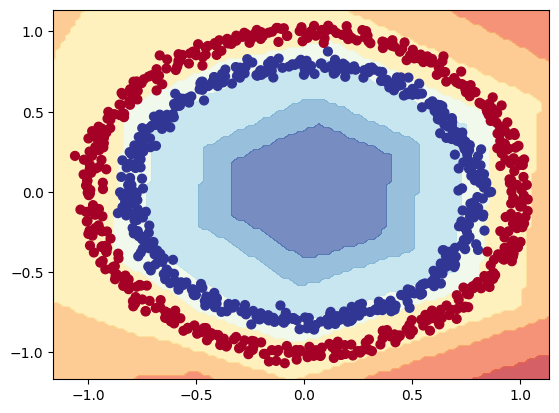

In [26]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [27]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 0.6989 - accuracy: 0.5050
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6972 - accuracy: 0.5020
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6961 - accuracy: 0.4970
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6951 - accuracy: 0.4960
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6943 - accuracy: 0.4940
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6937 - accuracy: 0.5030
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6929 - accuracy: 0.5070
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6923 - accuracy: 0.4990
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6917 - accuracy: 0.5000
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6911 - accuracy: 0.5020
Epoch 11/

In [28]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.4684 - accuracy: 0.8540


[0.468388170003891, 0.8539999723434448]

313/313 [==============================] - 0s 1ms/step
doing binary classification


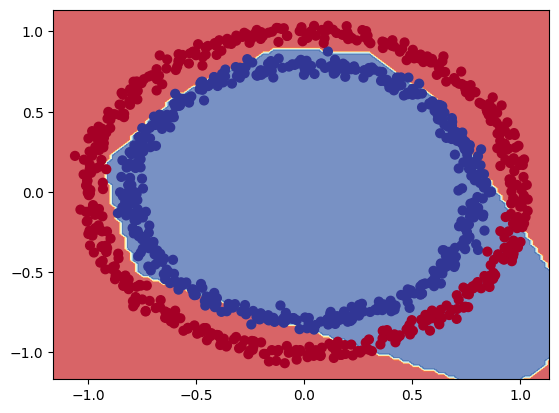

In [29]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [30]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [31]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 [==============================] - 1s 2ms/step - loss: 0.6927 - accuracy: 0.4837
Epoch 2/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6910 - accuracy: 0.5100
Epoch 3/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6892 - accuracy: 0.5063
Epoch 4/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6868 - accuracy: 0.5250
Epoch 5/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6824 - accuracy: 0.5700
Epoch 6/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6726 - accuracy: 0.5312
Epoch 7/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6545 - accuracy: 0.6300
Epoch 8/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6238 - accuracy: 0.7050
Epoch 9/25
25/25 [==============================] - 0s 1ms/step - loss: 0.5854 - accuracy: 0.7575
Epoch 10/25
25/25 [==============================] - 0s 1ms/step - loss: 0.5378 - accuracy: 0.8200
Epoch 11/25
25/25 [

In [32]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.0713 - accuracy: 0.9850


[0.07128642499446869, 0.9850000143051147]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


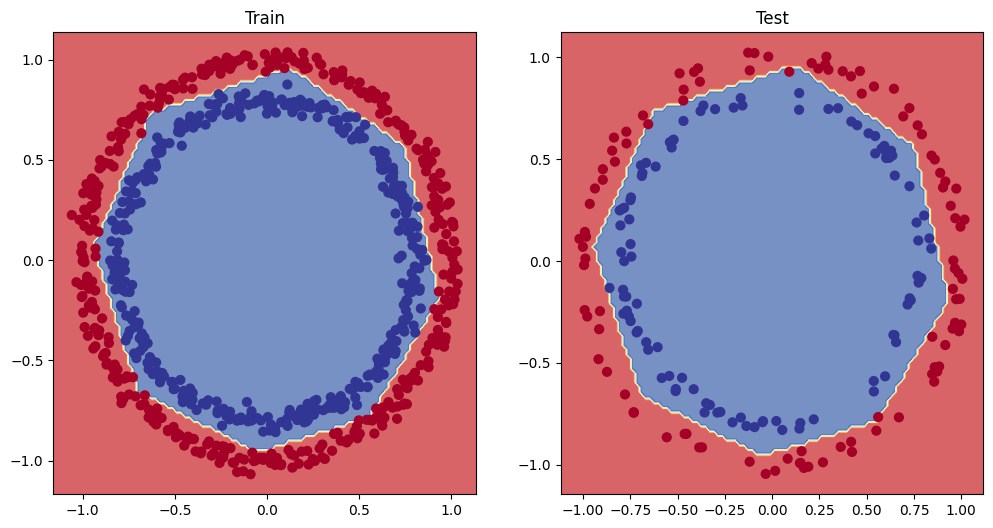

In [33]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [34]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.692659,0.48375
1,0.691042,0.51000
2,0.689170,0.50625
3,0.686839,0.52500
4,0.682411,0.57000
5,0.672627,0.53125
6,0.654489,0.63000
7,0.623755,0.70500
8,0.585438,0.75750
9,0.537772,0.82000


Text(0.5, 1.0, 'Model_8 loss curves')

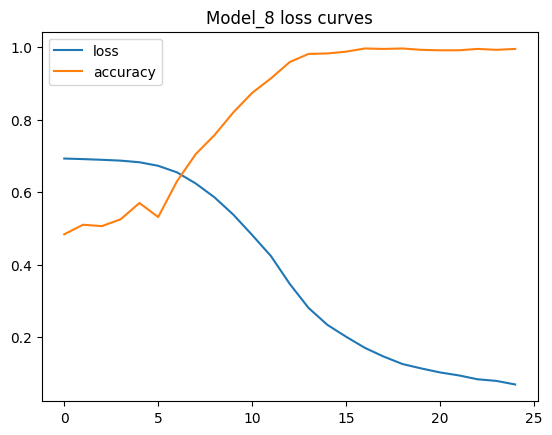

In [35]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")

## Finding the best learining rate

In [36]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_9.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# 3. Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(X_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 [==============================] - 1s 2ms/step - loss: 0.8491 - accuracy: 0.5075 - lr: 1.0000e-04
Epoch 2/100
25/25 [==============================] - 0s 2ms/step - loss: 0.8436 - accuracy: 0.5063 - lr: 1.1220e-04
Epoch 3/100
25/25 [==============================] - 0s 2ms/step - loss: 0.8378 - accuracy: 0.5000 - lr: 1.2589e-04
Epoch 4/100
25/25 [==============================] - 0s 1ms/step - loss: 0.8313 - accuracy: 0.5025 - lr: 1.4125e-04
Epoch 5/100
25/25 [==============================] - 0s 1ms/step - loss: 0.8247 - accuracy: 0.5013 - lr: 1.5849e-04
Epoch 6/100
25/25 [==============================] - 0s 1ms/step - loss: 0.8177 - accuracy: 0.5025 - lr: 1.7783e-04
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 0.8102 - accuracy: 0.4988 - lr: 1.9953e-04
Epoch 8/100
25/25 [==============================] - 0s 1ms/step - loss: 0.8026 - accuracy: 0.4875 - lr: 2.2387e-04
Epoch 9/100
25/25 [==============================] - 0s 1ms/step - loss:

<Axes: xlabel='epochs'>

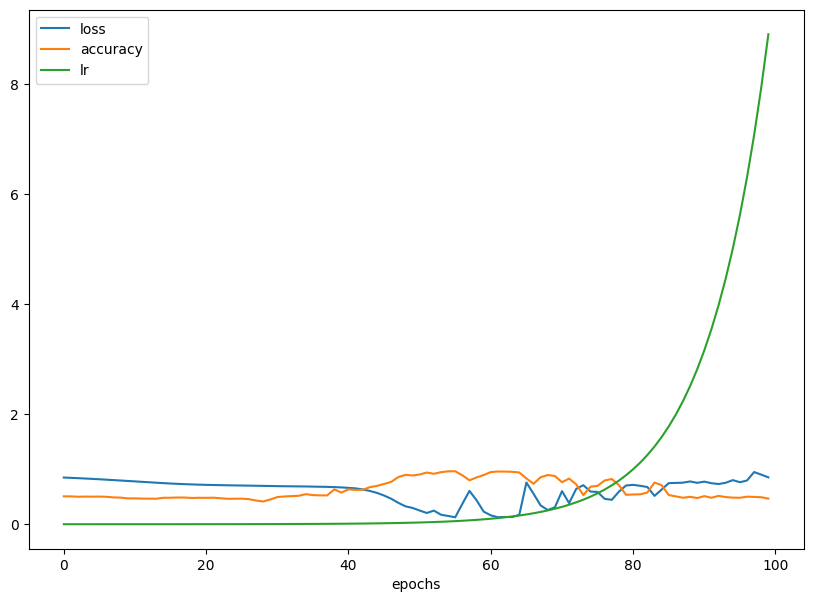

In [37]:
# Checout the history
pd.DataFrame(history_9.history).plot(figsize=(10, 7), xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

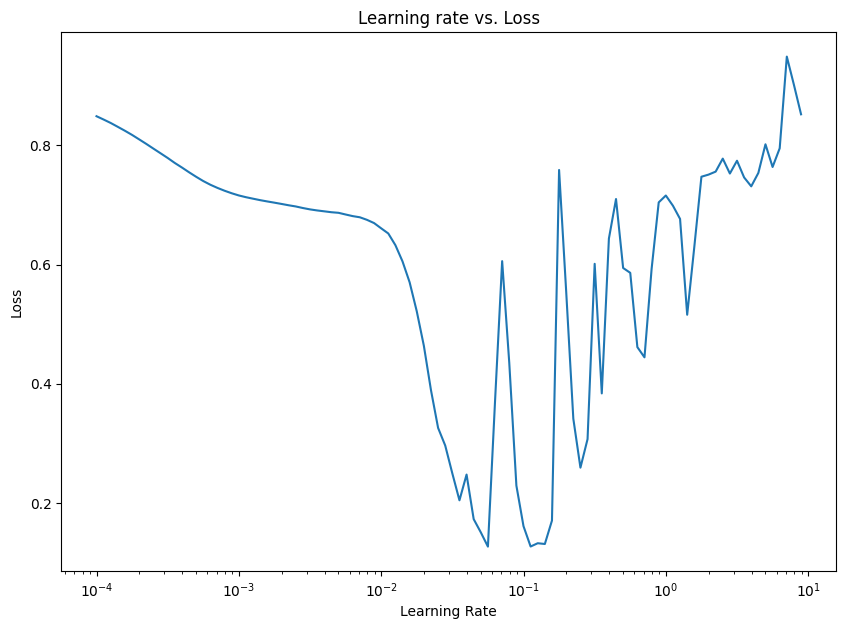

In [38]:
# Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")

In [39]:
# Let's try using a higher ideal learning rate with the same model as before

# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model with the ideal learning rate
model_10.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                   metrics=["accuracy"])

# Fit the model for 20 epochs (5 less than before)
history_10 = model_10.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 [==============================] - 1s 2ms/step - loss: 0.6965 - accuracy: 0.5213
Epoch 2/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6865 - accuracy: 0.5462
Epoch 3/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6779 - accuracy: 0.5400
Epoch 4/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6623 - accuracy: 0.5738
Epoch 5/20
25/25 [==============================] - 0s 1ms/step - loss: 0.6339 - accuracy: 0.6112
Epoch 6/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5830 - accuracy: 0.7113
Epoch 7/20
25/25 [==============================] - 0s 1ms/step - loss: 0.5406 - accuracy: 0.7175
Epoch 8/20
25/25 [==============================] - 0s 1ms/step - loss: 0.4923 - accuracy: 0.7887
Epoch 9/20
25/25 [==============================] - 0s 1ms/step - loss: 0.4608 - accuracy: 0.8050
Epoch 10/20
25/25 [==============================] - 0s 1ms/step - loss: 0.4349 - accuracy: 0.8112
Epoch 11/20
25/25 [

In [40]:
# 4. Evaluate model_10 on the test dataset
model_10.evaluate(X_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 0.3447 - accuracy: 0.8750


[0.3447490334510803, 0.875]

313/313 [==============================] - 0s 1ms/step
doing binary classification
313/313 [==============================] - 0s 1ms/step
doing binary classification


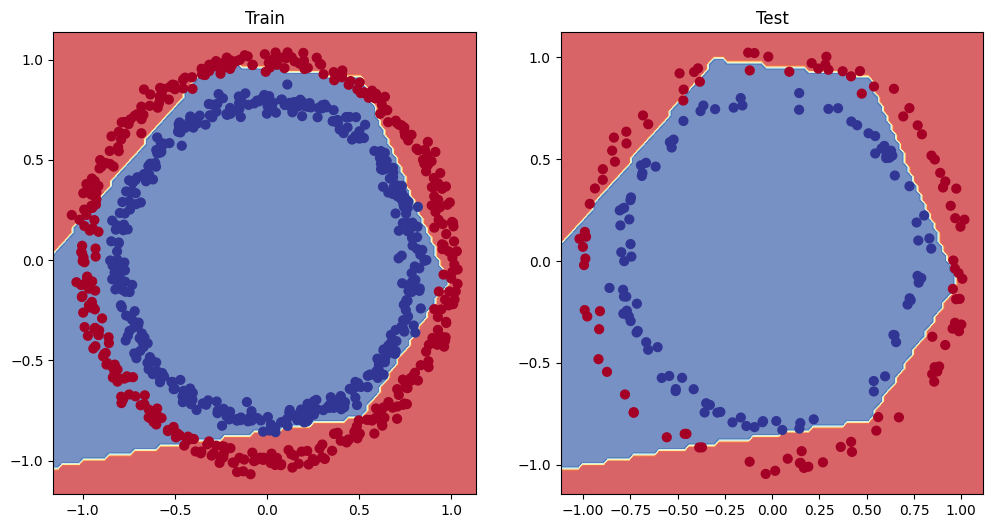

In [41]:
# plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_10, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_10, X_test, y_test)
plt.show()

In [42]:
# Check the accuracy of our model.
loss, accuracy = model_10.evaluate(X_test, y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {(accuracy*100):.2f}%")

7/7 [==============================] - 0s 2ms/step - loss: 0.3447 - accuracy: 0.8750
Model loss on the test set: 0.3447490334510803
Model accuracy on the test set: 87.50%


How about a confusion matrix?

In [43]:
# Create a confusion matrix
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = model_10.predict(X_test)

# Create confusion matrix
confusion_matrix(y_test, y_preds)

7/7 [==============================] - 0s 2ms/step


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [44]:
y_test[:10]

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [45]:
y_preds[:10]

array([[0.80845594],
       [0.80845594],
       [0.80845594],
       [0.80845594],
       [0.80845594],
       [0.80845594],
       [0.80845594],
       [0.19908348],
       [0.80845594],
       [0.00954976]], dtype=float32)

Looks like our predictions array has come out in prediction probability form... the standard output from the sigmoid (or softmax) activation function.

In [46]:
# Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [47]:
# Create a confusion matrix
confusion_matrix(y_test, tf.round(y_preds))

array([[76, 25],
       [ 0, 99]], dtype=int64)